# Import libraries

In [1]:
import cv2
import numpy as np
from utils import displayRectangle, show_roi_instructions

# Initialize video

In [2]:
path_to_video = '../../video/rijeka_tunell_car.mp4'
video = cv2.VideoCapture(path_to_video)

# Detect ROI

Bbox selected: (225, 640, 100, 73)


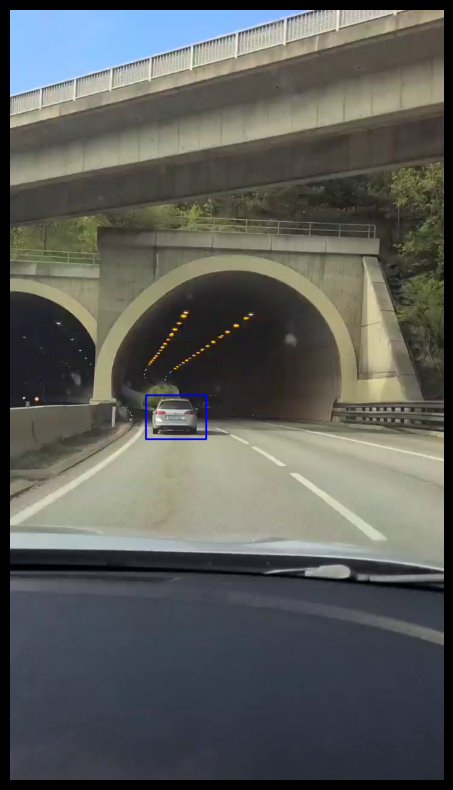

In [3]:
ok, frame = video.read()
if not ok:
    raise RuntimeError("Failed to read first frame")

show_roi_instructions(frame)

# Drag a rectangle with the mouse, press ENTER/SPACE to confirm, or ESC to cancel
object_template = cv2.selectROI("Select ROI", frame, showCrosshair=True, fromCenter=False)
cv2.destroyWindow("Select ROI")

# bbox is (x, y, w, h)
if object_template == (0, 0, 0, 0):
    raise RuntimeError("ROI selection canceled")


# video.release()
cv2.destroyAllWindows()

print(f'Bbox selected: {object_template}')
displayRectangle(frame, object_template)

In [4]:
x1, y1, w, h = map(int, object_template)
width, height = w, h

x2 = x1 + w
y2 = y1 + h

# Limit the search to a certain vicinity (since the cars can only move that fast)
search = 50

# Read the first frame used for template (already in `frame` after ROI selection)
# Build template as an image patch (grayscale, float32 in [0,1])
frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
template = frame_gray[y1:y1 + height, x1:x1 + width].astype(np.float32) / 255.0

In [5]:
# Limit the search to a certain vicinity (since the cars can only move that fast)
search = 50

cnt = 0
cv2.namedWindow("Tracking", cv2.WINDOW_NORMAL)

while True:
    ok, frame = video.read()
    if not ok:
        break

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

    # Clamp search window bounds to image
    H, W = frame_gray.shape[:2]
    sx1 = max(0, x1 - search)
    sy1 = max(0, y1 - search)
    sx2 = min(W, x1 + width + search)
    sy2 = min(H, y1 + height + search)

    search_window = frame_gray[sy1:sy2, sx1:sx2]

    # Tracking by minimising simple SAD (sum of absolute differences) loss
    # Equivalent to MSE loss (in **this** case) but faster
    track_x1 = None
    track_y1 = None
    loss = 1e6
    for r in range(0, search_window.shape[0] - height):
        for c in range(0, search_window.shape[1] - width):
            candidate = search_window[r:r+height, c:c+width]
            score = np.sum(np.abs(template - candidate))
            if score < loss:
                loss = score
                track_x1 = c
                track_y1 = r

    # Update the bounding box of the tracked object
    x1 = x1 - search + track_x1
    y1 = y1 - search + track_y1
    print(x1, y1, width, height)

    cnt = cnt + 1

    # Show the tracker working
    cv2.rectangle(frame, (x1, y1), (x1+width, y1+height), (0, 255, 0), 2)

    # 500 ms delay; press ESC to stop
    cv2.imshow("Tracking", cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    key = cv2.waitKey(1000) & 0xFF
    if key == 27:
        break

video.release()
cv2.destroyAllWindows()

226 640 100 73
226 640 100 73
228 640 100 73
225 640 100 73
227 639 100 73
229 639 100 73
231 639 100 73
233 639 100 73
235 639 100 73
237 639 100 73
239 639 100 73
241 639 100 73
243 639 100 73
244 639 100 73
246 639 100 73
248 639 100 73
250 639 100 73
254 639 100 73
257 639 100 73
259 639 100 73
260 639 100 73
261 639 100 73
262 639 100 73
294 599 100 73
296 598 100 73
298 599 100 73
300 597 100 73
301 597 100 73
302 598 100 73
299 597 100 73
303 596 100 73
305 596 100 73
307 596 100 73
309 596 100 73
310 596 100 73
311 596 100 73
314 597 100 73
317 597 100 73
322 597 100 73
324 597 100 73
326 598 100 73
339 598 100 73
344 598 100 73
348 598 100 73
350 598 100 73
354 598 100 73
355 598 100 73
305 548 100 73
282 553 100 73
246 505 100 73
226 473 100 73
251 504 100 73
249 497 100 73
